
**Case Study: Eniac’s Discount Strategy**


# Importing clean data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

In [ ]:
# orders_qc.csv
url = "https://drive.google.com/file/d/1XdxgRkpP-6QNIy3IxgMZmLcUviATaoad/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
#orders_qc = pd.read_csv(path)
orders_qc=pd.read_csv(path, parse_dates=["created_date"])


# orderlines_qc.csv
url = "https://drive.google.com/file/d/1AQ8m52gsMNqDrzyRTBqjUffjrbbTKrrs/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_qc=pd.read_csv(path, parse_dates=["orderlines_date"])

# products_qc.csv
url = "https://drive.google.com/file/d/1awVC0T6x8suaf7Rpzyb5qG-a1WDnVOQc/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_qc=pd.read_csv(path)

#brands
url = 'https://drive.google.com/file/d/1m1ThDDIYRTTii-rqM5SEQjJ8McidJskD/view?usp=drive_link'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
brands_df_original = pd.read_csv(path)

In [ ]:
# copy of all dataframes
orders_df = orders_qc.copy()
orderlines_df = orderlines_qc.copy()
products_df=products_qc.copy()
brands_df = brands_df_original.copy()

In [ ]:
# Display format
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_colwidth', None) # to increase the width of the columns

# **Data Analysis -Big picture**

* What is the time period that the dataset covers? (01-Jan-2017 to 14-Mar-2018)
* What is the overall revenue for that time? (15312354.04 Euro)
* Are there seasonal patterns in the evolution of sales? (yes)
* What are the most sold products?
* What are the products that generate the most revenue?

#### Time period of dataset

In [ ]:
orders_df["created_date"].max()

Timestamp('2018-03-14 12:03:52')

In [ ]:
orders_df["created_date"].min()

Timestamp('2017-01-01 01:51:47')

#### Overall revenue

In [ ]:
orders_df["total_paid"].sum()

np.float64(15312354.04)

#### Seasonal pattern in sales

In [ ]:
#Extract Month as a Name (Jan, Feb...)
orders_df['month_name'] = orders_df["created_date"].dt.strftime('%b')

In [ ]:
avg_month_orders = orders_df.groupby("month_name",as_index=False)["total_paid"].mean().round(2)
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
avg_month_orders = avg_month_orders.set_index('month_name').reindex(month_order).reset_index()

In [ ]:
avg_ord_price_time= sns.relplot(kind="line",
            data=avg_month_orders,
            x='month_name',
            y='total_paid',
            height= 4,aspect=1.5);
avg_ord_price_time.set(title="Trend in Average Order Price ", xlabel="Months", ylabel="Average Order Price (Euros)")
avg_ord_price_time.set_xticklabels(rotation=45);

#### Most sold products

In [ ]:
most_sold = orderlines_df.groupby("sku").agg(total_sold=('product_quantity', 'sum')).reset_index()

most_sold = most_sold.sort_values('total_sold', ascending=False)
most_sold.head(10)

# details
#most_sold_sku = most_sold['sku'].head(10)
#most_sold_products = orderlines_df.loc[orderlines_df['sku'].isin(most_sold_sku), :]
#most_sold_products

,sku,total_sold
528,APP1190,1015
408,APP0698,826
846,APP1922,551
5720,WDT0183,514
435,APP0927,493
1622,CRU0051,349
4664,SAM0074,347
549,APP1214,282
1138,APP2446,271
3365,NTE0013,264


#### Products with most revenue

In [ ]:
orderline_product_revenue= orderlines_df.merge(products_df, on="sku")

In [ ]:
orderline_product_revenue['revenue'] = orderline_product_revenue['unit_price'] * orderline_product_revenue['product_quantity']

In [ ]:
most_revenue= orderline_product_revenue.groupby("sku")["revenue"].sum().sort_values(ascending= False).reset_index()
most_revenue

,sku,revenue
0,APP2075,212411.11
1,APP2074,156383.56
2,APP2490,145274.00
3,LGE0044,139377.77
4,APP2489,134657.00
...,...,...
5910,KIN0125,3.99
5911,NTE0087-A,2.82
5912,PAR0037,1.99
5913,SEV0021,0.01


In [ ]:
orderline_product_revenue.nunique()

,0
id,59808
order_id,45238
product_quantity,27
sku,5915
orderlines_date,59152
unit_price,5764
unit_price_total,7009
name,5869
desc,4435
price,1402


# **Business Analysis Focus Areas**

* Classify products into clear, consistent categories to streamline reporting and enable easier comparative analysis.
* Analyze the distribution of product prices across categories to identify pricing patterns.
* Quantify the number of products currently offered with discounts.
* Evaluate discount percentages to understand promotional intensity.
* Assess the impact of seasonality and key retail events (e.g., Christmas, Black Friday) on sales performance.
* Identify opportunities to improve data collection for more accurate, complete, and actionable analysis

## Discount Analysis

* Discount is difference between orderlines.unit_price and products.price.
* Merging both tables and creating a column "price_discount".

In [ ]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10534 entries, 0 to 10533
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sku        10534 non-null  object 
 1   name       10534 non-null  object 
 2   desc       10534 non-null  object 
 3   price      10534 non-null  float64
 4   in_stock   10534 non-null  int64  
 5   type       10484 non-null  float64
 6   short_sku  10534 non-null  object 
dtypes: float64(2), int64(1), object(4)
memory usage: 576.2+ KB


In [ ]:
orderlines_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59808 entries, 0 to 59807
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                59808 non-null  int64         
 1   order_id          59808 non-null  int64         
 2   product_quantity  59808 non-null  int64         
 3   sku               59808 non-null  object        
 4   orderlines_date   59808 non-null  datetime64[ns]
 5   unit_price        59808 non-null  float64       
 6   unit_price_total  59808 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(1)
memory usage: 3.2+ MB


In [ ]:
# merging orderlines & products dataframes
orderline_product= orderlines_df.merge(products_df, on="sku")

orderline_product= orderline_product[["order_id","sku","name" ,"product_quantity","unit_price","price","in_stock", "type","orderlines_date"]]
orderline_product

,order_id,sku,name,product_quantity,unit_price,price,in_stock,type,orderlines_date
0,299545,OWC0100,OWC In-line Digital Temperature Sensor Kit HDD iMac 2011,1,47.49,60.99,1,12755395.00,2017-01-01 01:46:16
1,299546,IOT0014,iOttie Easy View 2 Car Black Support,1,18.99,22.95,0,5720.00,2017-01-01 01:50:34
2,295347,APP0700,"Apple 85W MagSafe 2 charger MacBook Pro screen Retina 15 ""(OEM)",1,72.19,89.00,1,13005399.00,2017-01-01 01:54:11
3,299549,PAC0929,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB | 2TB Drive Fusion",1,2565.99,3209.00,0,1282.00,2017-01-01 02:07:42
4,299556,CRU0039-A,(Open) Crucial 240GB SSD 7mm BX200,1,60.90,76.99,0,1298.00,2017-01-01 02:20:14
...,...,...,...,...,...,...,...,...,...
59803,527035,APP0698,Apple Lightning Cable Connector to USB 1m White (OEM),1,9.99,25.00,1,1230.00,2018-03-14 11:42:41
59804,527070,APP0698,Apple Lightning Cable Connector to USB 1m White (OEM),2,9.99,25.00,1,1230.00,2018-03-14 11:49:01
59805,527074,APP0698,Apple Lightning Cable Connector to USB 1m White (OEM),2,9.99,25.00,1,1230.00,2018-03-14 11:49:36
59806,527096,APP0698,Apple Lightning Cable Connector to USB 1m White (OEM),3,9.99,25.00,1,1230.00,2018-03-14 11:54:35


In [ ]:
orderline_product["price_discount"] = (orderline_product["price"] - orderline_product["unit_price"])

In [ ]:
orderline_product.head()

,order_id,sku,name,product_quantity,unit_price,price,in_stock,type,orderlines_date,price_discount
0,299545,OWC0100,OWC In-line Digital Temperature Sensor Kit HDD iMac 2011,1,47.49,60.99,1,12755395.00,2017-01-01 01:46:16,13.50
1,299546,IOT0014,iOttie Easy View 2 Car Black Support,1,18.99,22.95,0,5720.00,2017-01-01 01:50:34,3.96
2,295347,APP0700,"Apple 85W MagSafe 2 charger MacBook Pro screen Retina 15 ""(OEM)",1,72.19,89.00,1,13005399.00,2017-01-01 01:54:11,16.81
3,299549,PAC0929,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB | 2TB Drive Fusion",1,2565.99,3209.00,0,1282.00,2017-01-01 02:07:42,643.01
4,299556,CRU0039-A,(Open) Crucial 240GB SSD 7mm BX200,1,60.90,76.99,0,1298.00,2017-01-01 02:20:14,16.09


In [ ]:
orderline_product["order_id"].nunique()

45238

In [ ]:
orderline_product["sku"].nunique()

5915

In [ ]:
# total discount for each product
orderline_product.groupby("sku")["price_discount"].sum()

,price_discount
sku,
8MO0001-A,22.04
8MO0003-A,22.15
8MO0007,89.07
8MO0008,134.10
8MO0009,87.63
...,...
ZAG0040,13.00
ZAG0041,10.00
ZAG0042,10.00


###**Distribution of discounts applied to products**

In [ ]:
orderline_product["price_discount%"] = ((orderline_product["price_discount"]/ orderline_product["price"])*100)

In [ ]:
# Summarising all data for Discounts at order level
orders_aggregated = (
    orderline_product.groupby('order_id', as_index=False)
    .agg(
        product_count=('product_quantity', 'sum'),
        discount_pct=('price_discount%', 'mean')
    )
)

orders_aggregated= orders_aggregated.sort_values('product_count', ascending=False)
orders_aggregated

,order_id,product_count,discount_pct
27098,438871,72,13.41
39123,495987,50,23.09
41396,507768,37,-0.11
25640,432242,35,20.83
33353,468784,33,24.95
...,...,...,...
7,247643,1,14.70
45233,527042,1,60.03
45211,526956,1,60.03
45206,526907,1,26.98


In [ ]:
# Defining bins and labels
bins = [0, 10, 30, 100]
labels = ["Low", "Medium", "High"]

orders_aggregated['discount_gp'] = pd.cut(
    orders_aggregated['discount_pct'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [ ]:
orders_aggregated['discount_gp'].value_counts().reset_index()

,discount_gp,count
0,Medium,23331
1,Low,11262
2,High,8958


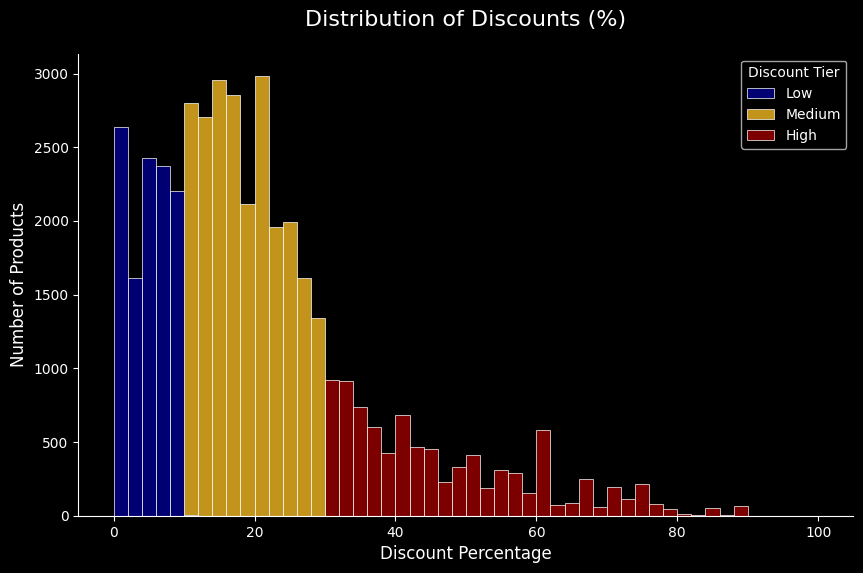

In [ ]:
# Plotting distribution of discounts in products

#  Setup Plotting Style
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

#  Plotting
custom_bins = np.arange(0, 101, 2)

ax = sns.histplot(
    data=orders_aggregated,
    x='discount_pct',
    hue='discount_gp',
    palette={'Low': 'navy', 'Medium': 'goldenrod', 'High': 'darkred'},
    bins=custom_bins,
    edgecolor='white',
    linewidth=0.5,
    alpha=0.9,
    #  to ensure the categories appear in the correct order in the legend
    hue_order=['Low', 'Medium', 'High']
)

# Refining the Visuals
plt.title("Distribution of Discounts (%)", fontsize=16, color='white', pad=20)
plt.xlabel("Discount Percentage", fontsize=12)
plt.ylabel("Number of Products", fontsize=12)

sns.move_legend(ax, "upper right", title='Discount Tier', frameon=True)
sns.despine()

plt.savefig('corrected_discount_plot.png')
plt.show()

###**Discounted vs Non discounted**

In [ ]:
orderline_product.describe().round(2)

,order_id,product_quantity,unit_price,price,in_stock,type,price_discount,price_discount%
count,59808.00,59808.00,59808.00,59808.00,59808.00,59797.00,59808.00,59808.00
mean,414869.50,1.12,240.08,272.90,0.57,65736271325024.05,32.82,13.34
std,65405.01,0.77,499.38,558.56,0.50,610095429849484.50,103.66,77.88
min,241423.00,1.00,0.01,2.99,0.00,1216.00,-2078.76,-1159.20
25%,363249.75,1.00,29.90,39.95,0.00,1433.00,5.01,7.64
50%,417835.50,1.00,70.39,89.95,1.00,11905404.00,15.01,16.67
75%,470406.00,1.00,186.58,217.98,1.00,12755395.00,35.65,27.14
max,527112.00,72.00,8287.80,9799.00,1.00,5740000000000000.00,1511.20,99.98


In [ ]:
# Finding the discount disctribution (Discounted vs Non discounted)
Is_Discounted = (orderline_product["price"] > orderline_product["unit_price"])
Is_Discounted.value_counts()

,count
True,54838
False,4970


In [ ]:
# Calculating discount percentage
discount_pct = Is_Discounted.value_counts(normalize=True) * 100
print(discount_pct)

True    91.69
False    8.31
Name: proportion, dtype: float64


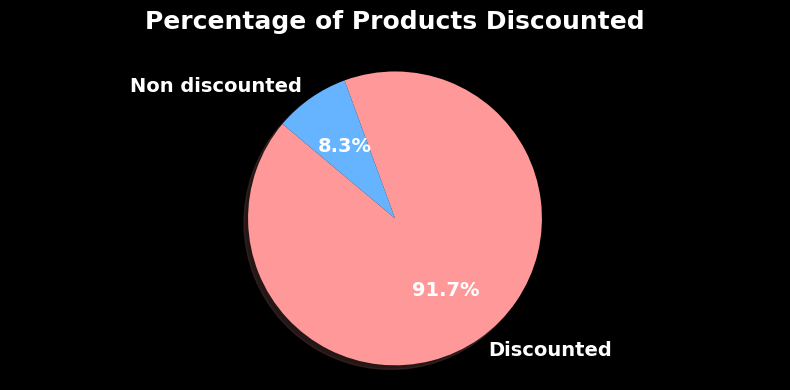

In [ ]:
# Plotting discounted vs non discounted products

# 1. Prepare the data from your value_counts()
labels = ['Discounted', 'Non discounted']
sizes = [91.69, 8.31]
colors = ['#ff9999','#66b3ff'] # Red for discounted (alert), Blue for full price


# 2. Set the style
plt.style.use('dark_background')
plt.figure(figsize=(8, 4))

# 3. Create the Pie Chart
plt.pie(sizes,
        #explode=explode,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%', # Adds the percentage labels automatically
        shadow=True,
        startangle=140,
        textprops={'fontsize': 14, 'fontweight': 'bold'})

# 4. Final Touches
plt.title('Percentage of Products Discounted', fontsize=18, fontweight='bold', pad=20)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

plt.tight_layout()
plt.savefig('discount_pie_chart.png')

* When exploring discounts, need to ensure to always have the **time** dimension in consideration, since Eniac does not always offer its products at the same price. A critical question, is whether revenue grows whenever discounts increase.

## Product categorisation

In order to simplify the analysis products were categorised.
**Type based mapping** used for accuracy & missing  type data mapped using keywords to ensure consistent grouping for reliable analysis.


In [ ]:
products_df.groupby("type")[["name", "desc"]].nunique()

,name,desc
type,,
1216.00,67,53
1229.00,107,67
1230.00,73,47
1231.00,10,10
1276.00,19,19
1280.00,5,5
1282.00,354,317
1296.00,187,179
1298.00,833,802


In [ ]:
product_category_df = products_df.copy()

In [ ]:
product_category_df["category"] = ""

### Type based mapping

In [ ]:
from collections import Counter

top_words_per_type = {}

for t in product_category_df["type"].dropna().unique():
    names = product_category_df.loc[product_category_df["type"] == t, "name"].dropna()

    words = []
    for name in names:
        if isinstance(name, str):
            words.extend(name.split())

    word_counts = Counter(words)
    top_words_per_type[t] = [w for w, _ in word_counts.most_common(5)]

top_words_df = pd.DataFrame.from_dict(
    top_words_per_type,
    orient="index",
    columns=["top1","top2","top3","top4","top5"]
).reset_index().rename(columns={"index":"type"})

top_words_df.head(130).tail(10)


,type,top1,top2,top3,top4,top5
111,21632158.00,|,Apple,Mac,Pro,RAM
112,21561716.00,Apple,iPhone,6,Like,new
113,79201715.00,Like,new,-,Apple,iPod
114,51902158.00,|,Apple,Macbook,Air,13
115,5185.00,Apple,Watch,the,1st,Gen.
116,113291716.00,Apple,iPhone,8,64GB,-
117,113281716.00,Apple,iPhone,8,Plus,-
118,113271716.00,Apple,iPhone,X,Space,Gray
119,113464259.00,Apple,TV,4K,32GB,64GB
120,5450000000000000.00,|,Second,hand,-,Apple


In [ ]:
type_category_map = {
    # Support
    8696: "Support", 1216: "Support", 1280: "Support", 5720: "Support",
    15435404: "Support", 12282: "Support",

    # Keyboard
    13855401: "Keyboard", 12575403: "Keyboard", 54025401: "Keyboard", 5401: "Keyboard",

    # Mouse
    1387: "Mouse",

    # Cables, Adaptors & Connectors
    1230: "Cables & Connectors", 1325: "Cables & Connectors", 12995397: "Cables & Connectors",
    13955395: "Cables & Connectors", 12355400: "Cables & Connectors",
    12755395: "Cables & Connectors", 14365395: "Cables & Connectors",
    5395: "Cables & Connectors", 1298: "Cables & Connectors",
    13615399: "Cables & Connectors", 12585395: "Cables & Connectors",
    11434: "Cables & Connectors", 5399: "Cables & Connectors",13005399:"Cables & Connectors",

    # Repair
    144000000000: "Repair", 146000000000: "Repair",

    # Headphone
    5384: "Headphone",

    # Router
    1334: "Router",

    #iMac Kits
    14305406: "iMac Kits",1433: "iMac Kits",54085407:"iMac Kits",

    #iMac/iPhone Battery
    10142: "iMac/iPhone Battery",1515:"iMac/iPhone Battery", 12645406:"iMac/iPhone Battery",

    # External recorder
    1424.00: "External Recorder",

    # Microphone
    1375.00:"Microphone",

    # iPad Kit
    21535407.00: "iPad Kit",

    # iPhone replacement kit
    21485407.00: "iPhone replacement kit",5407.00: "iPhone replacement kit",5406.00:"iPhone replacement kit",

    # MacBook case
    13835403: "MacBook case/bag",10230.00: "MacBook case/bag",1392.00: "MacBook case/bag",

    # iPhone case
    11865403: "iPhone case", 549000000000: "iPhone case", 5403: "iPhone case",

    # Memory/Storage
    1276: "Memory/Storage", 11935397: "Memory/Storage", 12655397: "Memory/Storage",
    1404: "Memory/Storage", 12175397: "Memory/Storage", 57445397: "Memory/Storage",
    12215397: "Memory/Storage", 1364: "Memory/Storage", 42945397: "Memory/Storage",
    1020000000000: "Memory/Storage",

    # iPhone
    11905404: "iPhone", 24821716: "iPhone", 51601716: "iPhone",
    85641716: "iPhone", 24811716: "iPhone", 85651716: "iPhone",
    1716: "iPhone", 21571716: "iPhone", 21561716: "iPhone",
    113291716: "iPhone", 113281716: "iPhone", 113271716: "iPhone",

    # iPad case
    12635403: "iPad case",

    # Monitor
    1296: "Monitor",

    # Accessories
    12285400: "iPhone Accessories",

    # Pointer / Pen
    1229: "Pointer/Pen", 101781405: "Pointer/Pen",

    # Media player
    4259: "Media player", 113464259: "Media player",

    # Protector
    14035403: "Protector", 13555403: "Protector", 1231: "Protector", 2425: "Protector",

    # Cleaning
    12085400: "Cleaning",

    # iMac
    1282: "iMac", 5740000000000000: "iMac", 544000000000: "iMac",
    5430000000000000: "iMac", 5720000000000000: "iMac",
    216000000000: "iMac", 118692158: "iMac",

    # Camera
    9094: "Camera", 5404: "Camera",

    #iPod
    11821715.00: "iPod",79201715.00: "iPod",

    # Tablet/iPad
    1405: "Tablet/iPad", 12141714: "Tablet/iPad", 42931714: "Tablet/iPad",
    13621714: "Tablet/iPad", 24861714: "Tablet/iPad", 51861714: "Tablet/iPad",
    1714: "Tablet/iPad", 51871714: "Tablet/iPad", 12051714: "Tablet/iPad",
    12031714: "Tablet/iPad", 106431714: "Tablet/iPad", 113851714: "Tablet/iPad",

    # Watch
    5405: "Watch", 24215399: "Watch", 2434: "Watch",
    2449: "Watch", 24885185: "Watch", 24895185: "Watch", 5185: "Watch",

    # Speaker
    5398: "Speaker",

    # Service
    20642062: "Service",

    # Software
    1416: "Software",

    # MacBook
    217000000000: "MacBook", 2158: "MacBook", 51882158: "MacBook",
    929000000000: "MacBook", 21622158: "MacBook",
    539000000000: "MacBook", 21632158: "MacBook",
    51902158: "MacBook", 5450000000000000: "MacBook", 51912158: "MacBook",

    # Remote / Sensor
    54864259: "Remote/Sensor", 11859: "Remote/Sensor"
}

In [ ]:
product_category_df["category"] = product_category_df["type"].map(type_category_map).fillna(product_category_df["category"])

In [ ]:
# finding the rows with missing "type" data
product_category_df.loc[
    product_category_df["category"]== ""	,
    :
].sort_values("category")

,sku,name,desc,price,in_stock,type,short_sku,category
146,SAN0017,SanDisk Cruzer Edge USB 2.0 Flash Drive 16GB,Pendrive USB 2.0 Mac and PC.,8.00,0,NaN,SAN,
2669,APP1179,Apple iPhone 6S Plus 16GB Space Gray,New iPhone 6S Plus 16GB Free.,859.00,0,NaN,APP,
2670,APP1180,Apple iPhone 6S Plus 16GB Gold,New iPhone 6S Plus 16GB Free.,859.00,0,NaN,APP,
2671,APP1181,Apple iPhone 6S Plus 16GB Rose Gold,New iPhone 6S Plus 16GB Free.,859.00,0,NaN,APP,
2672,APP1182,Apple iPhone 6S Plus 64GB Silver,New iPhone 6S Plus 64GB Free.,969.00,0,NaN,APP,
2673,APP1183,Apple iPhone 6S Plus 64GB Space Gray,New iPhone 6S Plus 64GB Free.,969.00,0,NaN,APP,
2674,APP1184,Apple iPhone 6S Plus 64GB Gold,New iPhone 6S Plus 64GB Free.,969.00,0,NaN,APP,
2675,APP1186,Apple iPhone 6s Plus 128GB Silver,New iPhone 6s Plus 128GB Libre.,749.00,0,NaN,APP,
2676,APP1187,Apple iPhone 6s Plus 128GB Space Gray,New iPhone 6s Plus 128GB Libre.,749.00,0,NaN,APP,
2677,APP1188,Apple iPhone 6s Plus 128GB Gold,New iPhone 6s Plus 128GB Libre.,749.00,0,NaN,APP,


In [ ]:
# mapping missing Type data  using keywords
rules = {
    "iPhone": "iPhone",
    "ipad": "Tablet/iPad",
    "Mac": "MacBook",
    "Drive|Memory|Synology": "Storage",
    "Headphones": "Headphone",
    "Thunderbolt":"Cables & Connectors",
    "Chime":"Speaker"

}

mask = product_category_df["type"].isna() | (product_category_df["type"] == 0)

for keyword, category in rules.items():
    product_category_df.loc[
        mask & product_category_df["name"].str.contains(keyword, case=False, na=False),
        "category"
    ] = category

In [ ]:
# checking for updates
product_category_df.loc[
    product_category_df["category"]== ""	,
    :
].sort_values("category")

,sku,name,desc,price,in_stock,type,short_sku,category


In [ ]:
product_category_df["category"].value_counts()

,count
category,
Memory/Storage,2556
Cables & Connectors,1625
iPhone case,1128
iMac,760
iPhone,737
iPad case,368
MacBook case/bag,363
Watch,354
iMac Kits,266


### Creating  Categories & subcategories

Since there were 34 categories, making it difficult for analysis, these were renamed as subcategory & grouped them into 10 categories.

In [ ]:
# Renaming "category" as "sub_category"
product_category_df["sub_category"] = product_category_df["category"]

In [ ]:
# Creating "category" column by mapping the subcategory
category_map = {
    # 1. Mobile Devices
    "iPhone": "Mobile Devices",
    "iPhone replacement kit": "Mobile Devices",
    "iPad Kit": "Mobile Devices",
    "Tablet/iPad": "Mobile Devices",
    "iPod": "Mobile Devices",

    # 2. Computers
    "MacBook": "Computers",
    "iMac": "Computers",

    # 3. Computer Accessories
    "Keyboard": "Computer Accessories",
    "Mouse": "Computer Accessories",
    "Monitor": "Computer Accessories",
    "Pointer/Pen": "Computer Accessories",

    # 4. Mobile Accessories
    "iPhone case": "Mobile Accessories",
    "iPad case": "Mobile Accessories",
    "MacBook case/bag": "Mobile Accessories",
    "iPhone Accessories": "Mobile Accessories",
    "Protector": "Mobile Accessories",

    # 5. Connectivity & Power
    "Cables & Connectors": "Connectivity & Power",
    "Router": "Connectivity & Power",

    # 6. Audio & Media
    "Headphone": "Audio & Media",
    "Speaker": "Audio & Media",
    "Microphone": "Audio & Media",
    "Media player": "Audio & Media",

    # 7. Storage
    "Memory/Storage": "Storage",
     "Storage": "Storage",

    # 8. Repair & Services
    "Repair": "Repair & Services",
    "Service": "Repair & Services",
    "iMac Kits": "Repair & Services",
    "iMac/iPhone Battery": "Repair & Services",

    # 9. Smart Devices & Cameras
    "Camera": "Smart Devices & Cameras",
    "Watch": "Smart Devices & Cameras",
    "Remote/Sensor": "Smart Devices & Cameras",

    # 10. Software & Others
    "Software": "Software & Others",
    "Cleaning": "Software & Others",
    "Support": "Software & Others",
    "External Recorder": "Software & Others"
}

In [ ]:
product_category_df["category"] = product_category_df["sub_category"].map(category_map)

In [ ]:
product_category_df["category"].value_counts()
#product_category_df["sub_category"].value_counts()

,count
category,
Storage,2561
Mobile Accessories,1977
Connectivity & Power,1760
Mobile Devices,1154
Computers,1004
Repair & Services,670
Smart Devices & Cameras,435
Computer Accessories,396
Audio & Media,361


In [ ]:
product_category_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10534 entries, 0 to 10533
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           10534 non-null  object 
 1   name          10534 non-null  object 
 2   desc          10534 non-null  object 
 3   price         10534 non-null  float64
 4   in_stock      10534 non-null  int64  
 5   type          10484 non-null  float64
 6   short_sku     10534 non-null  object 
 7   category      10534 non-null  object 
 8   sub_category  10534 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 740.8+ KB


## Category based Price Analysis

In [ ]:
# merging orderlines & product_category_df
orderline_product_cat= orderlines_df.merge(product_category_df, on="sku")

orderline_product_cat= orderline_product_cat[["order_id","sku","name" ,"product_quantity","unit_price","price","in_stock", "type","category","sub_category"]]
orderline_product_cat.head()

,order_id,sku,name,product_quantity,unit_price,price,in_stock,type,category,sub_category
0,299545,OWC0100,OWC In-line Digital Temperature Sensor Kit HDD iMac 2011,1,47.49,60.99,1,12755395.00,Connectivity & Power,Cables & Connectors
1,299546,IOT0014,iOttie Easy View 2 Car Black Support,1,18.99,22.95,0,5720.00,Software & Others,Support
2,295347,APP0700,"Apple 85W MagSafe 2 charger MacBook Pro screen Retina 15 ""(OEM)",1,72.19,89.00,1,13005399.00,Connectivity & Power,Cables & Connectors
3,299549,PAC0929,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB | 2TB Drive Fusion",1,2565.99,3209.00,0,1282.00,Computers,iMac
4,299556,CRU0039-A,(Open) Crucial 240GB SSD 7mm BX200,1,60.90,76.99,0,1298.00,Connectivity & Power,Cables & Connectors


In [ ]:
# Finding number of products for each category
orderline_product_cat.groupby("category",as_index=False)["sku"].count().sort_values(by= "sku",ascending= False)

,category,sku
9,Storage,15130
3,Connectivity & Power,10008
4,Mobile Accessories,9541
5,Mobile Devices,8629
1,Computer Accessories,4646
6,Repair & Services,3772
0,Audio & Media,3332
2,Computers,2210
7,Smart Devices & Cameras,1562
8,Software & Others,978


In [ ]:
# Number of unique products in each category (Group by category and count unique SKUs)
unique_products = orderline_product_cat.groupby("category", as_index=False)["sku"].nunique()

# Renaming the column for clarity and sort
unique_products = unique_products.rename(columns={"sku": "unique_product_count"})
unique_products = unique_products.sort_values(by="unique_product_count", ascending=False)

print(unique_products)

                  category  unique_product_count
9                  Storage                  1246
4       Mobile Accessories                  1230
3     Connectivity & Power                  1081
5           Mobile Devices                   731
2                Computers                   442
6        Repair & Services                   325
1     Computer Accessories                   284
0            Audio & Media                   237
7  Smart Devices & Cameras                   222
8        Software & Others                   117


In [ ]:
orderline_product_cat.nunique()

,0
order_id,45238
sku,5915
name,5869
product_quantity,27
unit_price,5764
price,1402
in_stock,2
type,122
category,10
sub_category,34


#### **Discount & Revenue Analysis per category**

In [ ]:
# Creating new columns: "price_discount" & "price_discount%"

orderline_product_cat["price_discount"] = (orderline_product_cat["price"] - orderline_product_cat["unit_price"])
orderline_product_cat["price_discount%"] = ((orderline_product_cat["price_discount"]/ orderline_product_cat["price"])*100)

In [ ]:
# Creating new column: "revenue"
orderline_product_cat['revenue'] = orderline_product_cat['unit_price'] * orderline_product_cat['product_quantity']

In [ ]:
# average discount% for each category
orderline_product_cat.groupby("category")["price_discount%"].mean().sort_values(ascending= False)

,price_discount%
category,
Mobile Accessories,28.57
Connectivity & Power,24.60
Software & Others,20.53
Smart Devices & Cameras,18.43
Computer Accessories,17.84
Computers,12.13
Audio & Media,9.94
Repair & Services,7.33
Storage,2.96


**Mobile Accessories**, **Connectivity & Power** and **Software/Others**  have the highest cumulative  average discounts, indicating heavy discounting in these categories

In [ ]:
# Summarising all data for product category
category_stats = (
    orderline_product_cat.groupby("category", as_index=False)
    .agg(
        order_count=('order_id', 'count'),
        avg_price=('price', 'mean'),
        min_price=('price', 'min'),
        max_price=('price', 'max'),
        total_revenue=("revenue","sum")
    )
    .round(2) # Clean up decimals
)

# Sort by order_count to see the most popular categories first
category_stats = category_stats.sort_values('order_count', ascending=False)

category_stats

,category,order_count,avg_price,min_price,max_price,total_revenue
9,Storage,15130,305.77,4.99,9799.00,4492215.00
3,Connectivity & Power,10008,77.88,4.79,3799.00,664571.45
4,Mobile Accessories,9541,52.33,7.90,349.00,381698.43
5,Mobile Devices,8629,373.72,2.99,3199.90,3148982.31
1,Computer Accessories,4646,219.08,4.90,1576.99,979095.43
6,Repair & Services,3772,104.17,2.99,807.97,337014.70
0,Audio & Media,3332,152.98,3.49,799.00,439489.87
2,Computers,2210,2215.28,23.60,8249.00,4368437.34
7,Smart Devices & Cameras,1562,205.19,15.00,1269.00,282105.58
8,Software & Others,978,56.41,7.99,689.00,49233.57


### **Orders per category**

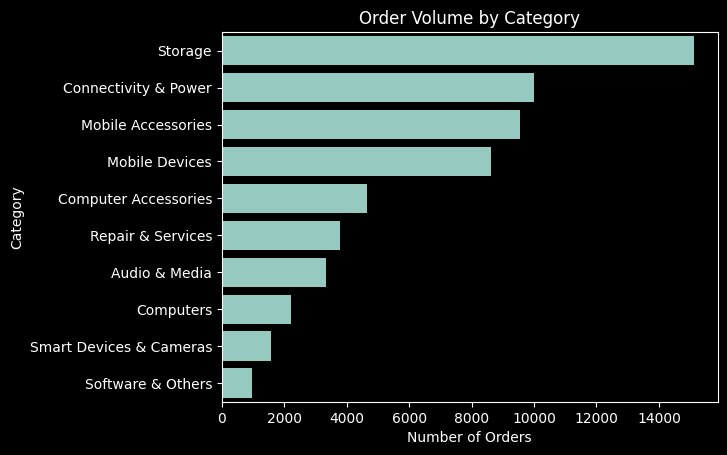

In [ ]:
# Plotting distribution of orders per category

sns.barplot(
    data=category_stats.sort_values("order_count", ascending=False),
    x="order_count",
    y="category"
)

plt.title("Order Volume by Category")
plt.xlabel("Number of Orders")
plt.ylabel("Category")
plt.show()

### **Revenue & Orders distribution across categories**

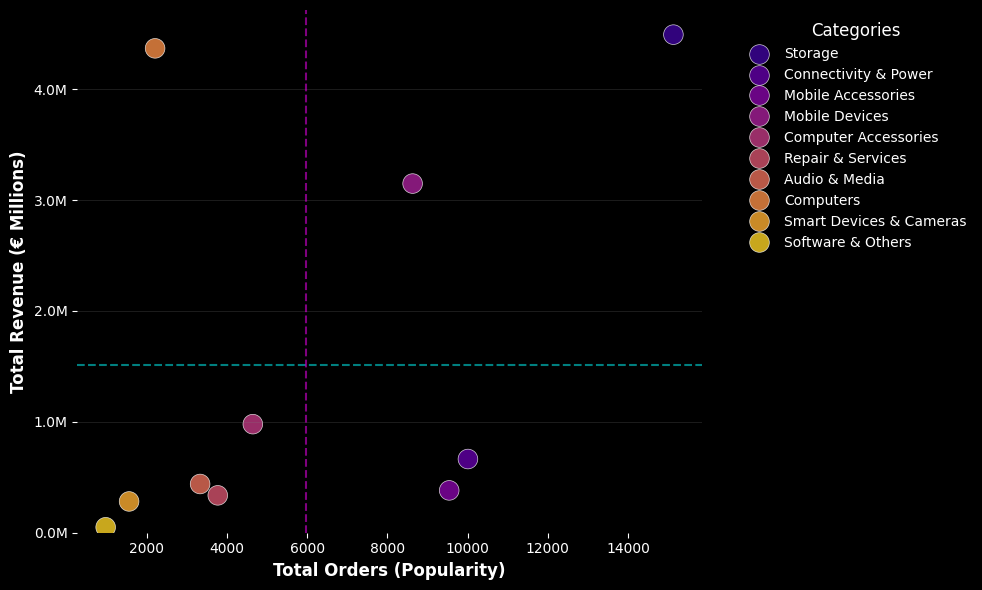

In [ ]:
# Plotting distribution. of orders & revenue across categories

#  Setting the dark theme
plt.style.use('dark_background')
plt.figure(figsize=(10, 6)) # Slightly wider for the legend

#  Defining a formatter function for Millions
def format_millions(x, pos):
    return f'{x/1e6:.1f}M' # Divides the number by 1,000,000 and adds 'M'

#  Creating the scatter plot
sns.scatterplot(
    data=category_stats,
    x='order_count',
    y='total_revenue',
    s=200,
    hue="category",
    palette='plasma',
    alpha=0.8,
    edgecolor='w',
    linewidth=0.5
)

#  Cleaning up borders and set Y-limit
sns.despine(left=True, bottom=True)
plt.ylim(0) # Forces the chart to start at €0 instead of €0.2M

#  Formatting Labels & Million Format
plt.xlabel('Total Orders (Popularity)', fontsize=12, fontweight='bold', color='white')
plt.ylabel('Total Revenue (€ Millions)', fontsize=12, fontweight='bold', color='white')
plt.xticks(color='white')

# Applying the Million formatter to the Y-axis
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_millions))
plt.yticks(color='white')

# Adjusting grid
plt.grid(axis='y', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)

#  Legend
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    frameon=False,
    title="Categories",
    title_fontsize='12',
    fontsize='10',
    labelcolor='white'
)

#  Baselines
plt.axhline(category_stats['total_revenue'].mean(), color='cyan', linestyle='--', alpha=0.5, label='Avg Revenue')
plt.axvline(category_stats['order_count'].mean(), color='magenta', linestyle='--', alpha=0.5, label='Avg Volume')

plt.tight_layout()
plt.show()

* **Computers** generate high revenue in spite of low orders volume, highlighting  it as a  premium, high-value category.
* **Mobile Devices** category which shows strong revenue with moderate volume, making them a balanced contributor.
* **Storage** is the top performer with both high orders and high revenue.
* **Remaining categories** fall below the average order & revenue  lines, indicating overall lower impact on sales.


### **Exploring Storage category**

Since Storage category seems to be a good performer , a deeper analysis performed by categorising it further based on the price.



In [ ]:
storage_cat= orderline_product_cat.loc[orderline_product_cat["category"]=="Storage",:]
storage_cat

,order_id,sku,name,product_quantity,unit_price,price,in_stock,type,category,sub_category,price_discount,price_discount%,revenue
8,299571,SYN0139,Synology DS216j NAS Server Mac and PC,1,166.24,175.99,0,12175397.00,Storage,Memory/Storage,9.75,5.54,166.24
14,299600,LAC0205,LaCie d2 Hard Drive 3TB Thunderbolt 2 USB 3.0,1,246.99,259.00,0,11935397.00,Storage,Memory/Storage,12.01,4.64,246.99
25,299634,SYN0146,Synology NAS Server DS416Play Mac and PC,1,369.54,434.99,0,12175397.00,Storage,Memory/Storage,65.45,15.05,369.54
26,299637,TOS0007,"Toshiba 1TB 25 ""SATA 5400rpm hard drive Mac and PC",1,53.19,62.99,1,12655397.00,Storage,Memory/Storage,9.80,15.56,53.19
27,299571,WDT0183,"Red 4TB WD 35 ""Mac PC hard drive and NAS",1,151.99,169.00,1,12655397.00,Storage,Memory/Storage,17.01,10.07,151.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...
59748,526641,OWC0039-2,Mac memory OWC 8GB (2x4GB) SO-DIMM DDR3 1600MHZ,1,87.99,93.98,1,1364.00,Storage,Memory/Storage,5.99,6.37,87.99
59756,526777,OWC0035-2,Mac memory OWC 8GB (2x4GB) SO-DIMM DDR3 1066MHZ,1,86.99,87.98,1,1364.00,Storage,Memory/Storage,0.99,1.13,86.99
59757,526778,SEA0049,"Seagate Barracuda 1TB Hard Drive 35 ""SATA for Mac and PC",1,41.20,59.00,1,12655397.00,Storage,Memory/Storage,17.80,30.17,41.20
59760,526843,LAC0206-A,Open - LaCie Porsche Design Desktop Lightgrey 4TB USB 3.0,1,108.23,139.99,0,11935397.00,Storage,Memory/Storage,31.76,22.69,108.23


In [ ]:
storage_cat = storage_cat.copy()

In [ ]:
# Creating new columns: "price_discount" & "price_discount%"
storage_cat["price_discount"] = (storage_cat["price"] - storage_cat["unit_price"])
storage_cat["price_discount%"] = ((storage_cat["price_discount"]/ storage_cat["price"])*100)

In [ ]:
# Creating new column: "revenue"
storage_cat['revenue'] = storage_cat['unit_price'] * storage_cat['product_quantity']

In [ ]:
storage_cat.describe().round(2)

,order_id,product_quantity,unit_price,price,in_stock,type,price_discount,price_discount%,revenue
count,15130.00,15130.00,15130.00,15130.00,15130.00,15130.00,15130.00,15130.00,15130.00
mean,408546.80,1.20,274.37,305.77,0.57,45720327097.92,31.39,2.96,296.91
std,65187.64,1.09,508.32,548.92,0.49,211032267597.47,78.97,98.82,524.14
min,241423.00,1.00,3.99,4.99,0.00,1276.00,-2078.76,-1159.20,3.99
25%,355048.25,1.00,76.99,89.99,0.00,11935397.00,8.00,6.83,80.99
50%,407980.50,1.00,124.99,139.99,1.00,11935397.00,20.20,13.86,135.99
75%,461847.25,1.00,229.90,255.00,1.00,12655397.00,40.00,21.43,265.98
max,526863.00,72.00,8287.80,9799.00,1.00,1020000000000.00,1511.20,90.97,8287.80


In [ ]:
storage_cat.groupby("sku")["price"].sum().sort_values(ascending= False)

,price
sku,
APP2075,228085.71
APP2074,171140.99
APP2264,94017.00
APP2266,92093.00
APP2080,82512.73
...,...
KIN0126,11.98
LEX0019,10.99
LEX0012,7.99


#### Creating price category for **Storage**

Inorder to understand how sales volume, revenue, and discounting interact across price segments, Storage category was further categorised based on price.

In [ ]:
# Defining the bins and the labels
bins = [0, 50, 250, 1000, 3000, 10000]
labels = [
    "Low Cost",
    "Budget",
    "Mid Range",
    "High Value",
    "Premium"
]

# Creating the new column
storage_cat['price_tier'] = pd.cut(storage_cat['price'], bins=bins, labels=labels)


In [ ]:
# Checking the distribution in each price tier
storage_cat['price_tier'].value_counts().reset_index()

,price_tier,count
0,Budget,9558
1,Mid Range,3023
2,Low Cost,1695
3,High Value,688
4,Premium,166


In [ ]:
# Summarising all data for Storage category
storage_stats = (
    storage_cat.groupby("price_tier", as_index= False)
    .agg(
        order_count=('order_id', 'count'),
        avg_price=('price', 'mean'),
        min_price=('price', 'min'),
        max_price=('price', 'max'),
        total_revenue=("revenue","sum"),
        total_discount=("price_discount","sum")
    )
    .round(2)
)

# Sorting by order_count to see the most popular categories first
storage_stats = storage_stats.sort_values('order_count', ascending=False)

storage_stats

/tmp/ipykernel_1075/1205783959.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  storage_cat.groupby("price_tier", as_index= False)


,price_tier,order_count,avg_price,min_price,max_price,total_revenue,total_discount
1,Budget,9558,131.82,50.28,249.99,1296377.11,155552.04
2,Mid Range,3023,446.00,250.99,989.00,1282025.91,177115.55
0,Low Cost,1695,31.47,4.99,49.99,83232.58,-13135.92
3,High Value,688,2013.49,1008.99,2989.00,1293984.04,109643.91
4,Premium,166,3490.46,3035.92,9799.00,536595.36,45820.53


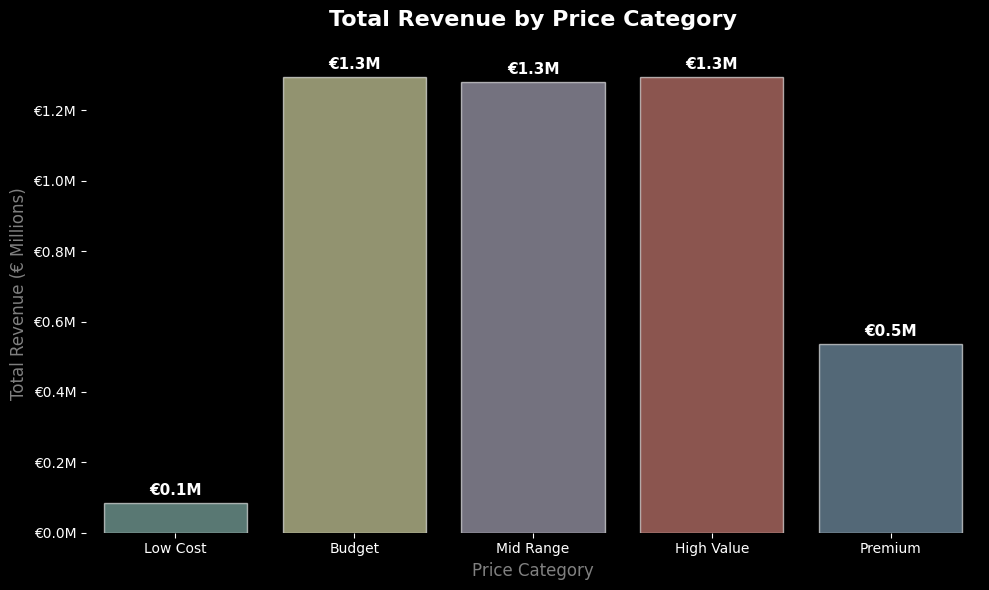

In [ ]:
# Plotting revenue across different price segments for Storage category

#  Setting Dark Mode Style
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

# Defining the order for the X-axis
price_order = ['Low Cost', 'Budget', 'Mid Range', 'High Value', 'Premium']

# Creating the Bar Chart
# Aggregating the revenue by price tier for the chart
ax = sns.barplot(
    data=storage_stats,
    x='price_tier',
    y='total_revenue',
    order=price_order,
    hue='price_tier',
    edgecolor='white',
    alpha=0.6
)

# Removing Borders (Despine)
sns.despine(left=True, bottom=True)

#  Formatting Y-Axis to Millions
def millions_formatter(x, pos):
    return f'€{x/1e6:.1f}M'

plt.gca().yaxis.set_major_formatter(FuncFormatter(millions_formatter))

#  Adding Data Labels on top of bars

for p in ax.patches:
    ax.annotate(f'€{p.get_height()/1e6:.1f}M',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=11, fontweight='bold', color='white')

#  Labels and Title
plt.title("Total Revenue by Price Category", fontsize=16, pad=20, fontweight='bold')
plt.xlabel("Price Category", fontsize=12, color='gray')
plt.ylabel("Total Revenue (€ Millions)", fontsize=12, color='gray')

plt.tight_layout()
plt.show()

####Price category Analysis with revenue, orders & discount

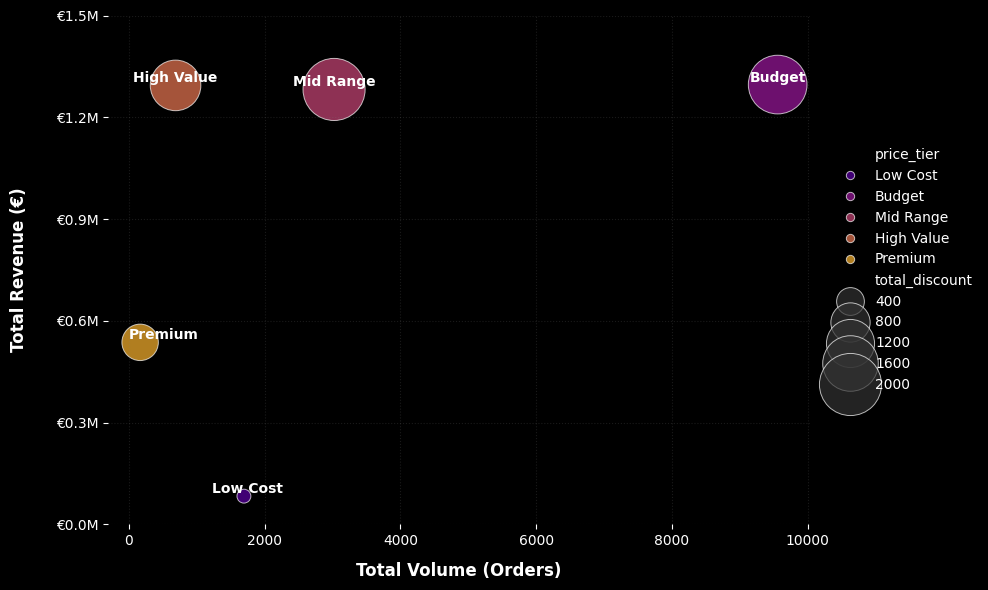

In [ ]:
# Plotting price category in relation to revenue, orders & discount

# Helper function to turn 1,000,000 into "1.0M"
def millions(x, pos):
    return f'€{x*1e-6:1.1f}M'


#  Seting up Style
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 6)) # Slightly wider for the legend

#  Using advanced Bubble Scaling
# Using a Min-Max scaler to keep bubbles between 100 and 2000 units
min_s, max_s = 100, 2000
raw_size = storage_stats["total_discount"]
bubble_size = ((raw_size - raw_size.min()) / (raw_size.max() - raw_size.min()) * (max_s - min_s) + min_s)

#  Creating the Scatter Plot
# Using 'hue' with 'price_tier' ensures all 5 categories get distinct plasma colors
scatter = sns.scatterplot(
    data=storage_stats,
    x='order_count',
    y='total_revenue',
    size=bubble_size,
    hue='price_tier',
    palette='plasma',
    sizes=(min_s, max_s),
    alpha=0.7,
    edgecolor='white',
    linewidth=0.7,
    legend='brief' # Ensures we see the price tiers in the legend
)

#  Smart Labeling (Adjusted for better clearance)
for tier in storage_stats['price_tier'].unique():
    subset = storage_stats[storage_stats['price_tier'] == tier]
    top_point = subset.loc[subset['total_revenue'].idxmax()]
    y_offset = storage_stats['total_revenue'].max() * 0.07
    size = bubble_size[top_point.name]
    y_offset = size * 0.02
    x_offset = size * 0.5
# Condition: large bubbles → above, small → right
    if size > 1000:
        x = top_point['order_count']
        y = top_point['total_revenue'] + y_offset
        ha = 'center'
        va = 'bottom'
    else:
        x = top_point['order_count'] + x_offset
        y = top_point['total_revenue']
        ha = 'left'
        va = 'center'
    plt.text(
        x,y,
        tier,
        fontsize=10,
        fontweight='bold',
        color='white',
        ha='center',
        va='bottom',
        bbox=dict(facecolor='none', alpha=0.5,edgecolor='none', pad=7)
    )

#  Cleaning up Borders and Grid
sns.despine(left=True, bottom=True)
plt.grid(axis='both', color='gray', linestyle=':', alpha=0.2)

#  Labels and Legend
plt.xlabel("Total Volume (Orders)", fontsize=12, fontweight='bold', color='white',labelpad=10)
plt.ylabel("Total Revenue (€)", fontsize=12, fontweight='bold', color='white', labelpad= 20)


# Applying helper function to the Y-axis
ax.yaxis.set_major_formatter(FuncFormatter(millions))
ax.set_ylim(0,1_500_000)
ax.set_yticks(np.linspace(0,1_500_000,6))

# Fixing the legend so it doesn't cover the bubbles
plt.legend(bbox_to_anchor=(1.02, 0.5), loc='center left',frameon= False)

plt.tight_layout()
plt.show()

The low-cost category appears to perform the weakest overall.
The budget segment demonstrates a strong positive relationship between order volume and revenue, suggesting that growth is primarily driven by high sales volume, although this relies heavily on substantial discounting.
Mid-range and high-value products generate higher overall revenue despite lower sales volumes, but this comes at the expense of relatively higher discounts.
In contrast, the premium segment achieves high revenue per order while requiring only minimal discounting.
Based on these insights, the recommended strategy is to reduce discounting in the mid-range segment to improve margins, leverage premium products as the main profit drivers, and use the budget segment to sustain overall sales volume.


##Seasonal patterns in sales

In [ ]:
orderline_product.head()

,order_id,sku,name,product_quantity,unit_price,price,in_stock,type,orderlines_date
0,299545,OWC0100,OWC In-line Digital Temperature Sensor Kit HDD iMac 2011,1,47.49,60.99,1,12755395.00,2017-01-01 01:46:16
1,299546,IOT0014,iOttie Easy View 2 Car Black Support,1,18.99,22.95,0,5720.00,2017-01-01 01:50:34
2,295347,APP0700,"Apple 85W MagSafe 2 charger MacBook Pro screen Retina 15 ""(OEM)",1,72.19,89.00,1,13005399.00,2017-01-01 01:54:11
3,299549,PAC0929,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB | 2TB Drive Fusion",1,2565.99,3209.00,0,1282.00,2017-01-01 02:07:42
4,299556,CRU0039-A,(Open) Crucial 240GB SSD 7mm BX200,1,60.90,76.99,0,1298.00,2017-01-01 02:20:14


In [ ]:
orderline_product['revenue'] = orderline_product['unit_price'] * orderline_product['product_quantity']
orderline_product["price_discount%"] = ((orderline_product["price_discount"]/ orderline_product["price"])*100)

In [ ]:
orderline_product.head()

,order_id,sku,name,product_quantity,unit_price,price,in_stock,type,orderlines_date,price_discount,revenue,price_discount%
0,299545,OWC0100,OWC In-line Digital Temperature Sensor Kit HDD iMac 2011,1,47.49,60.99,1,12755395.00,2017-01-01 01:46:16,13.50,47.49,22.13
1,299546,IOT0014,iOttie Easy View 2 Car Black Support,1,18.99,22.95,0,5720.00,2017-01-01 01:50:34,3.96,18.99,17.25
2,295347,APP0700,"Apple 85W MagSafe 2 charger MacBook Pro screen Retina 15 ""(OEM)",1,72.19,89.00,1,13005399.00,2017-01-01 01:54:11,16.81,72.19,18.89
3,299549,PAC0929,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB | 2TB Drive Fusion",1,2565.99,3209.00,0,1282.00,2017-01-01 02:07:42,643.01,2565.99,20.04
4,299556,CRU0039-A,(Open) Crucial 240GB SSD 7mm BX200,1,60.90,76.99,0,1298.00,2017-01-01 02:20:14,16.09,60.90,20.90


###Trend in Total products sold

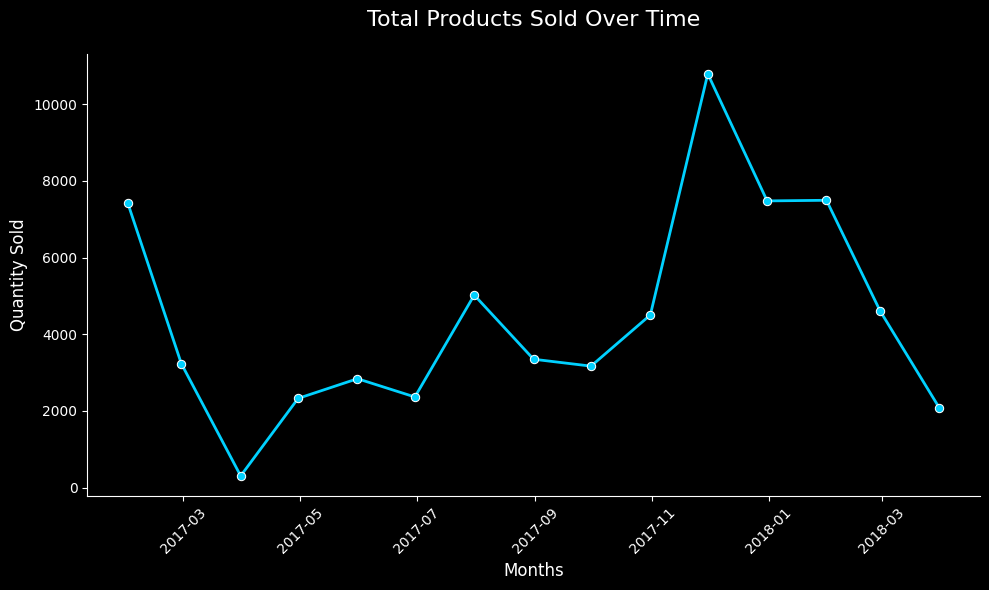

In [ ]:
# Plotting total products sold over months

# Grouping by date (months) and sum the quantity
products_over_time = (
    orderline_product.groupby(pd.Grouper(key='orderlines_date', freq='ME'))
    ['product_quantity'].sum()
    .reset_index()
)

# Setting up Style
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

# Plotting
sns.lineplot(
    data=products_over_time,
    x='orderlines_date',
    y='product_quantity',
    color='#00d1ff',
    marker='o',
    linewidth=2
)

# Refining the Visuals
plt.title("Total Products Sold Over Time", fontsize=16, pad=20)
plt.xlabel("Months", fontsize=12)
plt.ylabel("Quantity Sold", fontsize=12)

# Rotating dates for better readability
plt.xticks(rotation=45)

sns.despine()
plt.tight_layout()
plt.show()

###Trend in Revenue

In [ ]:
# Finding days with max sales
orderline_product.groupby("orderlines_date")["revenue"].sum().sort_values(ascending=False).head()

,revenue
orderlines_date,
2017-11-27 12:57:59,13387.77
2017-11-23 07:41:56,9080.14
2017-11-26 16:02:50,8287.80
2017-03-27 16:39:29,7952.97
2017-09-27 17:17:22,7335.59


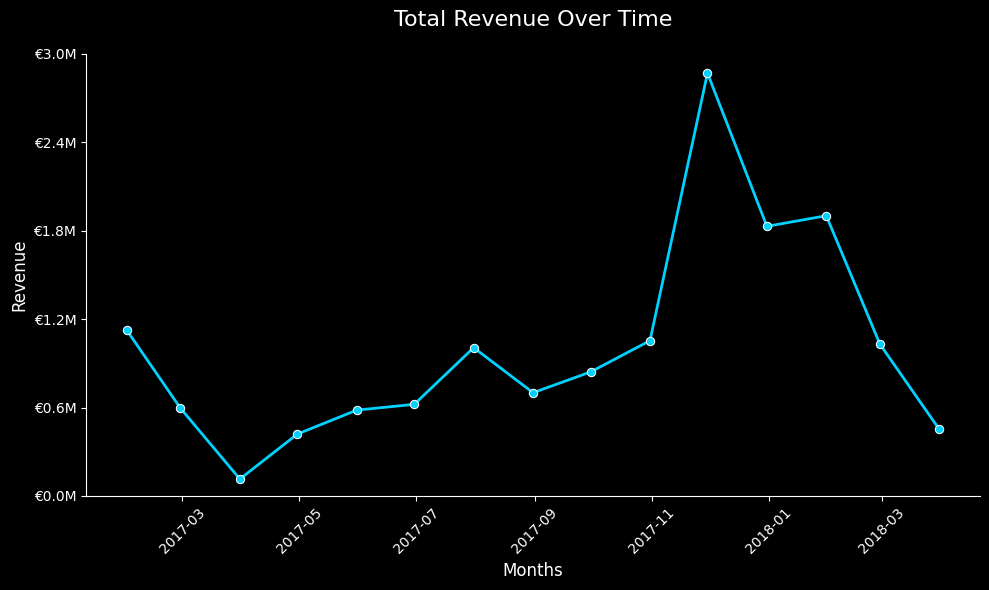

In [ ]:
# Plotting Total revenue over months

# Helper function to turn 1,000,000 into "1.0M"
def millions(x, pos):
    return f'€{x*1e-6:1.1f}M'

# Grouping by date (months) and sum the quantity
products_over_time = (
    orderline_product.groupby(pd.Grouper(key='orderlines_date', freq='ME'))
    ['revenue'].sum()
    .reset_index()
)

# Setting up Style
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

# Plotting
ax= sns.lineplot(
    data=products_over_time,
    x='orderlines_date',
    y='revenue',
    color='#00d1ff',
    marker='o',
    linewidth=2
)

# Applying helper function to the Y-axis
ax.yaxis.set_major_formatter(FuncFormatter(millions))
ax.set_ylim(0,3_000_000)
ax.set_yticks(np.linspace(0,3_000_000,6))



# Refining the Visuals
plt.title("Total Revenue Over Time", fontsize=16, pad=20)
plt.xlabel("Months", fontsize=12)
plt.ylabel(" Total Revenue", fontsize=12)

# Rotating dates for better readability
plt.xticks(rotation=45)

sns.despine()
plt.tight_layout()
plt.show()

###Trend in average discount

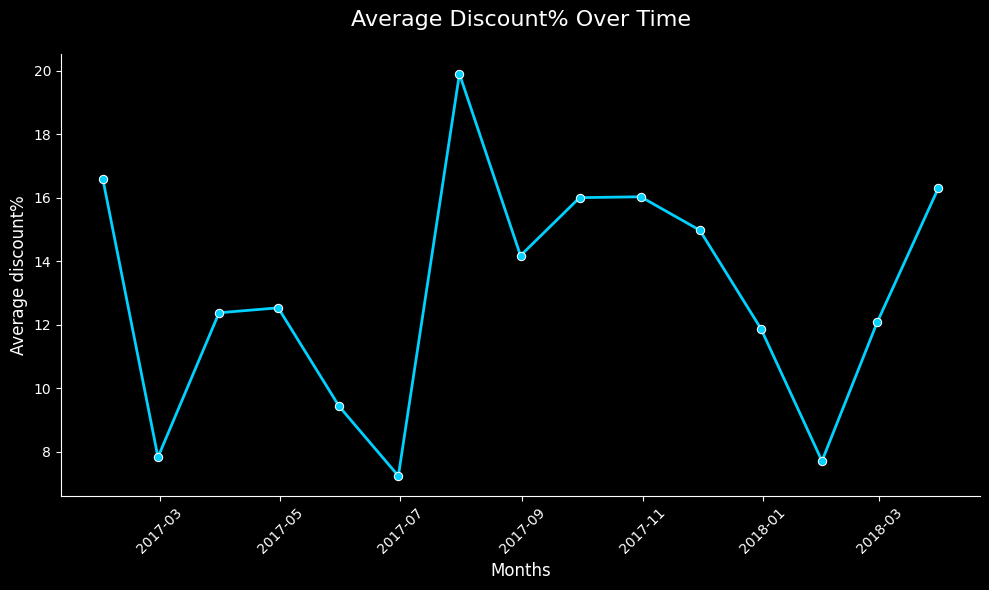

In [ ]:
# Plotting total products sold over months

# Grouping by date (months) and sum the quantity
products_over_time = (
    orderline_product.groupby(pd.Grouper(key='orderlines_date', freq='ME'))
    ['price_discount%'].mean()
    .reset_index()
)

# Setting up Style
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

# Plotting
sns.lineplot(
    data=products_over_time,
    x='orderlines_date',
    y='price_discount%',
    color='#00d1ff',
    marker='o',
    linewidth=2
)

# Refining the Visuals
plt.title("Average Discount% Over Time", fontsize=16, pad=20)
plt.xlabel("Months", fontsize=12)
plt.ylabel("Average discount%", fontsize=12)

# Rotating dates for better readability
plt.xticks(rotation=45)

sns.despine()
plt.tight_layout()
plt.show()

* Trends in products sold & revenue were  mostly identical
* Most Sales were in November 2017 (Black Friday week- 27, 26 & 23 November)
* Discounts are not related to revenue or product quantity

# **Recommendations based on Analysis**

* **Data Quality:** Ensure data integrity by allowing only valid price inputs, applying time-based discounts,
and checking for duplicates or missing values.
* **More Data:** Data over a longer timespan needed to have a fair comparison
* Since revenue is not driven by discounts, optimise discounts to high-demand events & avoid excessive discounts during regular periods where they do not significantly increase revenue.
* Optimize discounts in mid-range & focus on premium products to increase revenue in Storage category.
* More Analysis needed to identify discounting stratergy for other categories.

